# US Firm Characteristics: Feature Engineering

This notebook assembles the model matrix for the cross-sectional factor study. Its input is the
released Chen-Pelger-Zhu characteristic panel, which arrives already cross-sectionally
rank-transformed, and its output is `features/financial.parquet` keyed on the persistent anonymous
firm axis that `02_labels` keys its labels on.

Because the characteristics arrive ranked, this notebook fits nothing and looks back over nothing.
Every column it adds is a function of other columns *in the same row*. That makes the timing
contract in Section D unusually strong and unusually cheap to demonstrate: rebuilding the panel
with the holdout withheld reproduces every pre-holdout value exactly, and Section D.3 asserts it.

## Learning objectives

- Read a register that states, per family, what is expected to carry information and when it is
  knowable
- Separate the provider's update conventions from windows this notebook computes, and audit only
  what this notebook is in a position to audit
- Build composites and interactions without introducing a fitted transform
- Demonstrate a timing contract by rebuild-and-compare rather than by assertion in prose
- Emit a keyed artifact with a digest sidecar that the next stage reads

## Book reference, prerequisites and artifacts

Chapter 8, Section 8.4 (Contextual and Slow-Moving Features).

| | |
|---|---|
| Requires | [`02_labels`](02_labels.ipynb) - the label panel and its firm identity |
| Reads | `load_firm_characteristics()`; `labels/fwd_ret_1m.parquet` for the key check only |
| Writes | `features/financial.parquet` + `financial.parquet.digest.json` |
| Read by | [`04_evaluation`](04_evaluation.ipynb), and the modeling stages downstream of it |

The feature *screen* - information coefficients, HAC uncertainty, false-discovery control - is
not here. `04_evaluation` owns it and runs it fold-aware; a screen run once over the whole
development period, as an appendix to construction, reports a number no fold ever saw.

In [1]:
"""US Firm Characteristics: Feature Engineering."""

import warnings
from datetime import date

import polars as pl
import yaml

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    assert_values_agree,
    families_from_config,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    warmup_audit,
)
from data import load_firm_characteristics
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("us_firm_characteristics")
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"

Production runs both dates as `None` and takes the window from `setup.yaml`; CI overrides them
to shorten it. There is no firm cap: every family below is cross-sectional, so capping the
cross-section would change the ranks rather than the runtime.

In [2]:
START_DATE = None
END_DATE = None

## Configuration

The window, the register, the label name and the holdout boundary are declared in
`config/setup.yaml` and bound here. A window retyped in the notebook is a second source of truth
for a decision that the register, the warmup audit and the timing figure all have to agree on.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FAMILIES = families_from_config(setup)
WINDOW = setup["features"]["window"]
PRIMARY_LABEL = setup["labels"]["primary"]
HOLDOUT_START = date.fromisoformat(str(setup["evaluation"]["holdout_start"]))

WINDOW_START = date.fromisoformat(START_DATE) if START_DATE else WINDOW["start"]
WINDOW_END = date.fromisoformat(END_DATE) if END_DATE else WINDOW["end"]

# The panel key, and the partition every within-date statistic is taken over.
ENTITY = "symbol"
PANEL_KEY = ["symbol", "timestamp"]

print(f"{len(FAMILIES)} declared families; window {WINDOW_START} to {WINDOW_END}")
print(f"Label {PRIMARY_LABEL}; holdout starts {HOLDOUT_START}; Section D rebuilds without it")

11 declared families; window 1990-01-01 to 2016-12-31
Label fwd_ret_1m; holdout starts 2016-01-01; Section D rebuilds without it


## A. What the thesis says should carry information

The thesis is cross-sectional and it is not one claim but six: among roughly 2,500 firms a month,
the ones that are cheap against fundamentals, more profitable, growing their asset base less
aggressively, and trending, earn the higher subsequent return, read against a risk and liquidity
state that says how much of that ordering is tradable.

The register below is declared in `config/setup.yaml::features.families` rather than here, for the
same reason the label name and the holdout boundary are: it states what the feature set *is*, and
a statement only the notebook holds cannot be read by a test, by a later stage, or by anyone
asking what changed between two runs.

One column of it needs reading with care. `lag` is fully sourced - the release publishes its
update conventions, and an annual variable is published at the end of June against a December
fiscal year end, so six months separate the accounting period from the decision that may use it.
`lookback` is not equally sourced: the release does not publish a per-characteristic estimation
window. Where a characteristic names its own window it is used (`r36_13` reads 36 months back to
13); otherwise the entry is the span of one provider observation. Section B says what follows from
that, and Section D audits only what this notebook is in a position to audit.

In [4]:
register = register_frame(FAMILIES)
print(register.select("family", "role", "lookback (bars)", "lag (bars)", "frame"))

shape: (11, 5)
┌────────────────────────┬────────┬─────────────────┬────────────┬───────────────┐
│ family                 ┆ role   ┆ lookback (bars) ┆ lag (bars) ┆ frame         │
│ ---                    ┆ ---    ┆ ---             ┆ ---        ┆ ---           │
│ str                    ┆ str    ┆ i64             ┆ i64        ┆ str           │
╞════════════════════════╪════════╪═════════════════╪════════════╪═══════════════╡
│ value                  ┆ signal ┆ 12              ┆ 6          ┆ cross section │
│ quality                ┆ signal ┆ 12              ┆ 6          ┆ cross section │
│ investment             ┆ signal ┆ 24              ┆ 6          ┆ cross section │
│ momentum               ┆ signal ┆ 36              ┆ 0          ┆ cross section │
│ risk                   ┆ state  ┆ 12              ┆ 0          ┆ cross section │
│ …                      ┆ …      ┆ …               ┆ …          ┆ …             │
│ composite accounting   ┆ signal ┆ 12              ┆ 6          ┆ cross

## B. Inputs and their observability

`load_firm_characteristics(split="all")` returns the released panel: one row per firm-month,
46 characteristics, a realized return and the authors' split label. This notebook consumes the
46 characteristics and the panel key. It does not consume `ret` - the label panel is built by
`02_labels`, and reading a realized return here would put the outcome in the feature matrix.

**The firm identity is the load-bearing input.** `symbol` is the persistent anonymous firm axis
recovered from the published tensors, and it is what `02_labels` keys on. An earlier vintage of
this notebook's output was keyed on a *positional* identifier - 1..N within each month, where N is
that month's cross-section size - which is why the shipped matrix carried ids `1..2826` while the
labels carried `1000000..2007140`, and joined to nothing. Section E asserts the join rather than
trusting it.

**What observability means for a panel that arrives ranked.** The provider computed each
characteristic's window and applied its own publication convention before releasing the panel, and
it releases complete cases only. Two consequences follow, and both constrain what Section D can
claim. The leading nulls that a rolling window leaves behind were removed upstream, so this panel
cannot evidence the windows in the register. And no null policy of this notebook's own is needed
for the released columns, because there are no nulls in them - Section E asserts that rather than
assuming it.

In [5]:
firm_chars = load_firm_characteristics(split="all").with_columns(pl.col("timestamp").cast(pl.Date))
firm_chars = firm_chars.filter(
    pl.col("timestamp").is_between(pl.lit(WINDOW_START), pl.lit(WINDOW_END))
)

CONSUMED = ["timestamp", "symbol", "ret", "split"]
RELEASED = [c for c in firm_chars.columns if c not in CONSUMED]

print(f"Loaded {len(firm_chars):,} firm-months over {firm_chars['timestamp'].n_unique()} months")
print(f"Period {firm_chars['timestamp'].min()} to {firm_chars['timestamp'].max()}")
print(f"Persistent anonymous firms: {firm_chars['symbol'].n_unique():,}")
print(f"Released characteristics consumed: {len(RELEASED)}")

Loaded 804,530 firm-months over 324 months
Period 1990-01-31 to 2016-12-30
Persistent anonymous firms: 9,861
Released characteristics consumed: 46


## C. Feature construction

Three subsections, and none of them fits a parameter or reads another row.

### C.1 The released characteristics, carried through unchanged

The 46 characteristics arrive already cross-sectionally rank-transformed onto the symmetric
interval the register records under `representation`, and Section E prints the range they
actually span. They are carried through as they arrive. Re-ranking them
here would be a second cross-sectional transform over a quantity that is already one, and a
rolling z-score over a bounded rank is a statistic of the ranking, not of the firm.

In [6]:
features = firm_chars.select(PANEL_KEY + RELEASED)
print(f"Released characteristics carried through: {len(RELEASED)}")

Released characteristics carried through: 46


### C.2 Within-family and cross-family composites

Seven equal-weight means: one per accounting family, one over the two 12-month momentum
characteristics, and three cross-family pairs. Averaging ranks cancels characteristic-specific
noise while keeping the members' scale, so a composite is comparable with the columns it averages.

Each mean divides by the number of members that are present in that row rather than by the family
size, so a composite is null only where every member is null. Section D.2 asserts exactly that,
because a mean that silently reads a shorter member list is the difference between a composite and
whichever of its members happened to be published.

In [7]:
def family_mean(df: pl.DataFrame, columns: list[str], alias: str) -> pl.DataFrame:
    """Row-wise mean over *columns*, dividing by the per-row non-null count."""
    present = [c for c in columns if c in df.columns]
    total = pl.sum_horizontal(pl.col(c) for c in present)
    count = pl.sum_horizontal(pl.col(c).is_not_null().cast(pl.Int32) for c in present)
    return df.with_columns(
        pl.when(count > 0).then(total / count).otherwise(None).alias(alias),
    )

In [8]:
MEMBERS = {family.name: [c for c in RELEASED if family.matches(c)] for family in FAMILIES}
MOMENTUM_12M = [c for c in ("r12_2", "r12_7") if c in RELEASED]

features = family_mean(features, MEMBERS["value"], "composite_value")
features = family_mean(features, MEMBERS["quality"], "composite_quality")
features = family_mean(features, MEMBERS["investment"], "composite_investment")
features = family_mean(features, MOMENTUM_12M, "composite_momentum")

features = features.with_columns(
    ((pl.col("composite_value") + pl.col("composite_quality")) / 2).alias(
        "composite_value_quality"
    ),
    ((pl.col("composite_value") + pl.col("composite_momentum")) / 2).alias(
        "composite_value_momentum"
    ),
    ((pl.col("composite_quality") + pl.col("composite_momentum")) / 2).alias(
        "composite_quality_momentum"
    ),
)

COMPOSITES = [c for c in features.columns if c.startswith("composite_")]
print(f"Composites: {len(COMPOSITES)} - {', '.join(COMPOSITES)}")

Composites: 7 - composite_value, composite_quality, composite_investment, composite_momentum, composite_value_quality, composite_value_momentum, composite_quality_momentum


### C.3 Interactions

Four products of two ranks each, for theses that are conditional rather than additive: cheap is
worth more when the firm is also profitable, and momentum reads differently at high idiosyncratic
volatility. Because the members are centred on zero, the product encodes *agreement* - it is
positive when both ranks sit on the same side of the cross-section and negative when they
disagree, and it is large at both extremes, which is the failure mode the register records.

In [9]:
features = features.with_columns(
    (pl.col("BEME") * pl.col("PROF")).alias("interaction_value_x_quality"),
    (pl.col("BEME") * pl.col("ROE")).alias("interaction_value_x_roe"),
    (pl.col("r12_2") * pl.col("IdioVol")).alias("interaction_momentum_x_ivol"),
    (pl.col("LME") * pl.col("BEME")).alias("interaction_size_x_value"),
)

INTERACTIONS = [c for c in features.columns if c.startswith("interaction_")]
CONSTRUCTED = COMPOSITES + INTERACTIONS
FEATURE_COLS = RELEASED + CONSTRUCTED
print(f"Interactions: {len(INTERACTIONS)}")
print(
    f"Feature matrix: {len(FEATURE_COLS)} columns ({len(RELEASED)} released, "
    f"{len(CONSTRUCTED)} constructed)"
)

Interactions: 4
Feature matrix: 57 columns (46 released, 11 constructed)


## D. The timing contract

### D.1 Every operation, and the window it sees

| Operation | Where | Rows it reads | Window |
|---|---|---|---|
| Window filter | B | its own row | none |
| Carry released characteristic | C.1 | its own row | none |
| Family mean | C.2 | its own row, member columns | none |
| Product of two ranks | C.3 | its own row | none |

No feature is built by a rolling operation, an expanding operation, a ranking or a
cross-sectional aggregate: every value in the matrix is a function of its own row. Sections E
and F do group by timestamp, to count coverage and to take within-month percentiles for the
figures, but nothing they compute is written to the artifact. The provider's windows are
upstream and are recorded in the register; the figure below draws them so that a reader of the
model matrix knows what each column spans, even though the span was not computed here.

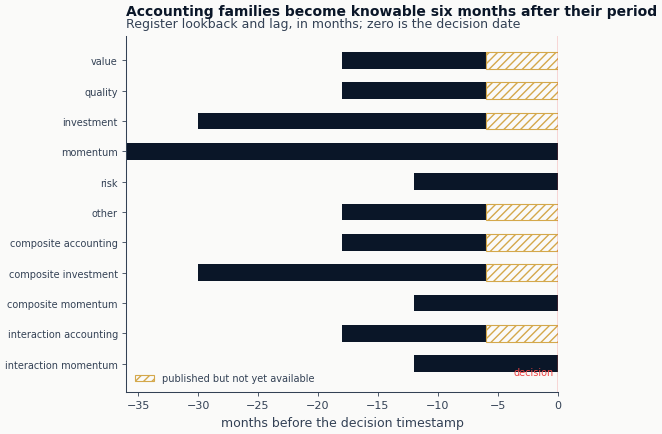

In [10]:
plot_timing_contract(
    FAMILIES,
    bar_unit="months",
    title="Accounting families become knowable six months after their period",
    subtitle=("Register lookback and lag, in months; zero is the decision date"),
    alt=(
        "Horizontal bars, one per register family, spanning the months each family's window "
        "reads and ending at a gap equal to the months before it becomes knowable. Eleven bars: "
        "seven end six months short of the decision timestamp - value, quality, investment, "
        "other, and the accounting composite and interaction groups - and four reach it, being "
        "momentum, risk, and the momentum composite and interaction groups. Momentum spans the "
        "longest window at 36 months; investment and the investment composite span 24."
    ),
)

### D.2 Warmup, asserted

`warmup_audit` holds each constructed column to the number of bars its window spans and raises if
a column is populated earlier than that, or is null everywhere.

**What this audit can and cannot establish here, stated rather than implied.** The released
characteristics are complete cases: their warmup nulls were removed by the provider before
release, so holding them to the register's lookbacks would fail on every one of them and would be
measuring the provider's screen rather than this notebook's construction. They are therefore not
in the audit. The constructed columns are functions of their own row and span no window of their
own, so their declared floor is zero and the branch that fires for them is the one that catches a
column that is null everywhere - which is what a mis-typed member list produces.

**A nullity check would be vacuous here, so it is not the evidence.** The obvious second check -
that a composite is null exactly where all its members are null - compares two conditions that
are both false on every row of a complete panel, so it passes whatever the composites contain.
It is kept below because it is the check that would bite on an incomplete release, and it is
labelled as vacuous rather than reported as though it had discriminated.

What can actually fail is the member list. Two assertions cover it: the register's patterns must
partition the 46 released columns - each claimed exactly once, no family empty - and each
composite must equal the mean of its declared members recomputed by a separate route. A mistyped
pattern breaks the first; a fault in `family_mean` breaks the second.

In [11]:
census = warmup_audit(features, dict.fromkeys(CONSTRUCTED, 0), entity=ENTITY)
print(census)

COMPOSED_OF = {
    "composite_value": MEMBERS["value"],
    "composite_quality": MEMBERS["quality"],
    "composite_investment": MEMBERS["investment"],
    "composite_momentum": MOMENTUM_12M,
}

# 1. the register partitions the released columns: claimed exactly once, no family empty
claimed = [c for family in FAMILIES for c in RELEASED if family.matches(c)]
assert sorted(claimed) == sorted(RELEASED), (
    "the register does not claim the released columns exactly once: "
    f"{sorted(set(claimed) ^ set(RELEASED))} claimed twice or not at all"
)
assert all(MEMBERS[f.name] for f in FAMILIES if any(f.matches(c) for c in RELEASED)), (
    "a register family matching released columns resolved to an empty member list"
)

# 2. each composite equals the mean of its declared members, recomputed separately
for name, members in COMPOSED_OF.items():
    independent = features.select(members).mean_horizontal()
    gap = (features[name] - independent).abs().max()
    assert gap is not None and gap < 1e-12, (
        f"{name} does not equal the mean of {members}: max gap {gap}"
    )
print(f"Register claims all {len(RELEASED)} released columns exactly once")
print(f"All {len(COMPOSED_OF)} composites equal the mean of their declared members")

# 3. kept for an incomplete release, and vacuous on this one - say so rather than score it
rows_all_members_null = sum(
    features.filter(pl.all_horizontal(pl.col(c).is_null() for c in members)).height
    for members in COMPOSED_OF.values()
)
for name, members in COMPOSED_OF.items():
    all_null = pl.all_horizontal(pl.col(c).is_null() for c in members)
    assert features.filter(pl.col(name).is_null() != all_null).height == 0
print(
    f"Nullity check passed on {len(features):,} rows and is VACUOUS: "
    f"{rows_all_members_null} rows have all members of any composite null"
)

shape: (11, 4)
┌─────────────────────────────┬────────────────────────┬─────────────────────┬───────────┐
│ column                      ┆ declared warmup (bars) ┆ first populated bar ┆ populated │
│ ---                         ┆ ---                    ┆ ---                 ┆ ---       │
│ str                         ┆ i64                    ┆ i64                 ┆ bool      │
╞═════════════════════════════╪════════════════════════╪═════════════════════╪═══════════╡
│ composite_value             ┆ 0                      ┆ 1                   ┆ true      │
│ composite_quality           ┆ 0                      ┆ 1                   ┆ true      │
│ composite_investment        ┆ 0                      ┆ 1                   ┆ true      │
│ composite_momentum          ┆ 0                      ┆ 1                   ┆ true      │
│ composite_value_quality     ┆ 0                      ┆ 1                   ┆ true      │
│ …                           ┆ …                      ┆ …                 

### D.3 Rebuild without the holdout, and compare

The strongest available statement about look-ahead is not that no transform was fitted, it is that
withholding the holdout changes nothing. The panel is rebuilt from the pre-holdout rows alone and
compared value by value against the full build cut back to the same rows. A trailing statistic
reads only its own row's history and a within-row statistic reads only its own row, so both are
unchanged; a parameter fitted over a whole column is not, and this comparison finds it without
anyone having remembered to flag it.

In [12]:
def build(panel: pl.DataFrame) -> pl.DataFrame:
    """Run C.1 to C.3 over *panel*, so the rebuild is the same code path as the build."""
    out = panel.select(PANEL_KEY + RELEASED)
    out = family_mean(out, MEMBERS["value"], "composite_value")
    out = family_mean(out, MEMBERS["quality"], "composite_quality")
    out = family_mean(out, MEMBERS["investment"], "composite_investment")
    out = family_mean(out, MOMENTUM_12M, "composite_momentum")
    out = out.with_columns(
        ((pl.col("composite_value") + pl.col("composite_quality")) / 2).alias(
            "composite_value_quality"
        ),
        ((pl.col("composite_value") + pl.col("composite_momentum")) / 2).alias(
            "composite_value_momentum"
        ),
        ((pl.col("composite_quality") + pl.col("composite_momentum")) / 2).alias(
            "composite_quality_momentum"
        ),
    )
    return out.with_columns(
        (pl.col("BEME") * pl.col("PROF")).alias("interaction_value_x_quality"),
        (pl.col("BEME") * pl.col("ROE")).alias("interaction_value_x_roe"),
        (pl.col("r12_2") * pl.col("IdioVol")).alias("interaction_momentum_x_ivol"),
        (pl.col("LME") * pl.col("BEME")).alias("interaction_size_x_value"),
    )

In [13]:
agreement = assert_values_agree(
    features.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START)),
    build(firm_chars.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START))),
    columns=FEATURE_COLS,
    keys=PANEL_KEY,
)
print(f"Rebuilt without the holdout: {len(FEATURE_COLS)} columns agree on every pre-holdout row")
print(agreement.head())

Rebuilt without the holdout: 57 columns agree on every pre-holdout row
shape: (5, 4)
┌────────┬───────────────┬───────────────────────┬────────────────────┐
│ column ┆ rows compared ┆ null only on one side ┆ max abs difference │
│ ---    ┆ ---           ┆ ---                   ┆ ---                │
│ str    ┆ i64           ┆ i64                   ┆ f64                │
╞════════╪═══════════════╪═══════════════════════╪════════════════════╡
│ A2ME   ┆ 780882        ┆ 0                     ┆ 0.0                │
│ AC     ┆ 780882        ┆ 0                     ┆ 0.0                │
│ AT     ┆ 780882        ┆ 0                     ┆ 0.0                │
│ ATO    ┆ 780882        ┆ 0                     ┆ 0.0                │
│ BEME   ┆ 780882        ┆ 0                     ┆ 0.0                │
└────────┴───────────────┴───────────────────────┴────────────────────┘


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`, and it is asserted unique. Two columns of the released
panel are excluded, each for a stated reason:

| Excluded | Reason |
|---|---|
| `ret` | the realized return, which is the outcome; `02_labels` owns it |
| `split` | the authors' own train/test partition, superseded by this study's `evaluation` block |

**One null policy, applied once.** The release publishes complete cases, so the policy is to
assert completeness rather than to impose a rule: every released characteristic must be fully
populated over the window, and every constructed column must be populated wherever its members
are. Nothing is dropped. The previous version of this notebook dropped rows on whichever five
columns happened to sort first in the released panel, which is a screen keyed on column order -
it removed nothing on this data, and would have removed something arbitrary on any other.

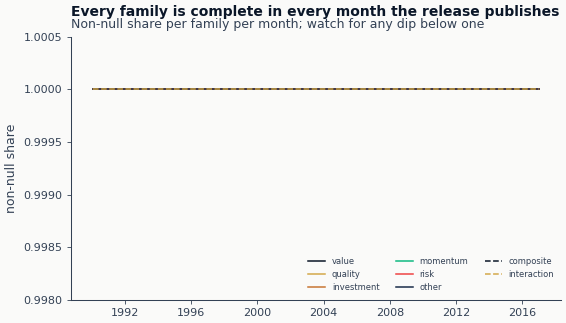

In [14]:
assert features.select(PANEL_KEY).n_unique() == len(features), "panel key is not unique"

null_counts = {c: features[c].null_count() for c in FEATURE_COLS}
populated = {c: n for c, n in null_counts.items() if n}
assert not populated, f"released panel is not complete: {populated}"

labels = (
    pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")
    .select(PANEL_KEY)
    .filter(pl.col("timestamp").is_between(pl.lit(WINDOW_START), pl.lit(WINDOW_END)))
)
joined = features.select(PANEL_KEY).join(labels, on=PANEL_KEY, how="inner")
assert joined.height == len(features) == labels.height, (
    f"feature and label identities do not align one to one: {len(features):,} features, "
    f"{labels.height:,} labels, {joined.height:,} joined - the two panels are keyed on "
    "different firm identities"
)

coverage = (
    features.group_by("timestamp")
    .agg(
        [
            pl.mean_horizontal(pl.col(c).is_not_null() for c in members).mean().alias(family)
            for family, members in MEMBERS.items()
            if members
        ]
        + [
            pl.mean_horizontal(pl.col(c).is_not_null() for c in COMPOSITES)
            .mean()
            .alias("composite"),
            pl.mean_horizontal(pl.col(c).is_not_null() for c in INTERACTIONS)
            .mean()
            .alias("interaction"),
        ]
    )
    .sort("timestamp")
)

plot_coverage_through_time(
    coverage,
    title="Every family is complete in every month the release publishes",
    subtitle=("Non-null share per family per month; watch for any dip below one"),
    alt=(
        "Non-null share per feature family plotted monthly. All eight families sit flat at "
        "1.0 across the whole window, with no dips."
    ),
)

### E. What the matrix contains

The cell below is the matrix as it will be written: its row count, its key, its per-month
cross-section, and the number of columns in each register family.

In [15]:
per_month = features.group_by("timestamp").len()["len"]
print(f"Rows: {len(features):,}   key: {' + '.join(PANEL_KEY)}")
print(f"Firms: {features['symbol'].n_unique():,}   months: {features['timestamp'].n_unique()}")
print(
    f"Cross-section per month: min {per_month.min():,}  median {int(per_month.median()):,}  "
    f"max {per_month.max():,}"
)
print(f"Features: {len(FEATURE_COLS)}")
released_min = min(features[c].min() for c in RELEASED)
released_max = max(features[c].max() for c in RELEASED)
print(f"Released characteristics span [{released_min:.3f}, {released_max:.3f}]")
print(register_frame(FAMILIES, columns=FEATURE_COLS).select("family", "columns", "role"))

Rows: 804,530   key: symbol + timestamp
Firms: 9,861   months: 324
Cross-section per month: min 1,933  median 2,577  max 2,826
Features: 57
Released characteristics span [-0.500, 0.500]
shape: (11, 3)
┌────────────────────────┬─────────┬────────┐
│ family                 ┆ columns ┆ role   │
│ ---                    ┆ ---     ┆ ---    │
│ str                    ┆ i64     ┆ str    │
╞════════════════════════╪═════════╪════════╡
│ value                  ┆ 6       ┆ signal │
│ quality                ┆ 7       ┆ signal │
│ investment             ┆ 6       ┆ signal │
│ momentum               ┆ 8       ┆ signal │
│ risk                   ┆ 8       ┆ state  │
│ …                      ┆ …       ┆ …      │
│ composite accounting   ┆ 5       ┆ signal │
│ composite investment   ┆ 1       ┆ signal │
│ composite momentum     ┆ 1       ┆ signal │
│ interaction accounting ┆ 3       ┆ signal │
│ interaction momentum   ┆ 1       ┆ signal │
└────────────────────────┴─────────┴────────┘


## F. What the features look like

Four descriptive views: shape, spread through time, redundancy, and persistence. None of them
states an information coefficient - `04_evaluation` owns predictive strength and computes it
fold-aware. What these establish is whether the columns are shaped the way the register says they
are, and whether they are distinct enough and stable enough to be worth screening at all.

**Every view below reads development rows only.** Section E wrote the full panel, because the
artifact has to carry the holdout rows for a later stage to score them. This section is
different: it is where a reader decides which features are worth carrying forward, and the
redundancy clusters in particular are what `04_evaluation` uses to pick one representative per
cluster. A judgement made about the feature set is selection, whether or not a metric is
attached to it, so it is made on the rows before the boundary.

In [16]:
development = features.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START))
print(
    f"Section F reads {len(development):,} of {len(features):,} rows "
    f"({development['timestamp'].max()} is the last, holdout starts {HOLDOUT_START})"
)

Section F reads 780,882 of 804,530 rows (2015-12-31 is the last, holdout starts 2016-01-01)


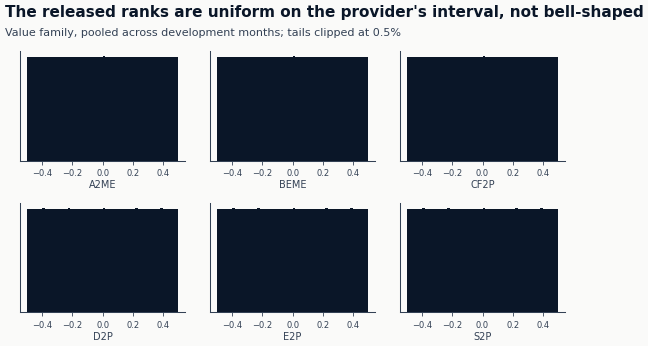

In [17]:
plot_feature_distributions(
    development,
    MEMBERS["value"],
    title="The released ranks are uniform on the provider's interval, not bell-shaped",
    subtitle="Value family, pooled across development months; tails clipped at 0.5%",
    alt=(
        "Six histograms, one per value characteristic. Each is flat across the interval "
        "minus 0.5 to 0.5 rather than peaked in the middle, which is what a cross-sectional "
        "rank transform produces."
    ),
)

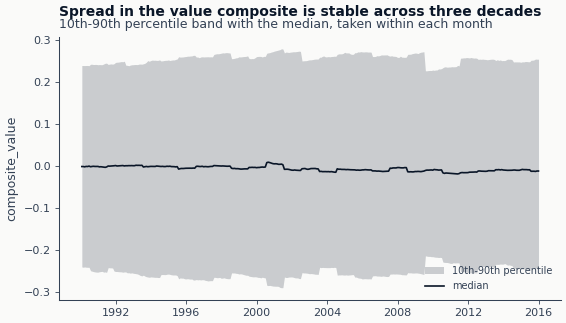

In [18]:
plot_cross_sectional_dispersion(
    development,
    "composite_value",
    title="Spread in the value composite is stable across three decades",
    subtitle="10th-90th percentile band with the median, taken within each month",
    alt=(
        "A band between the 10th and 90th percentile of the value composite computed within "
        "each month, with the median through it. The band holds a near-constant width across "
        "the window."
    ),
)

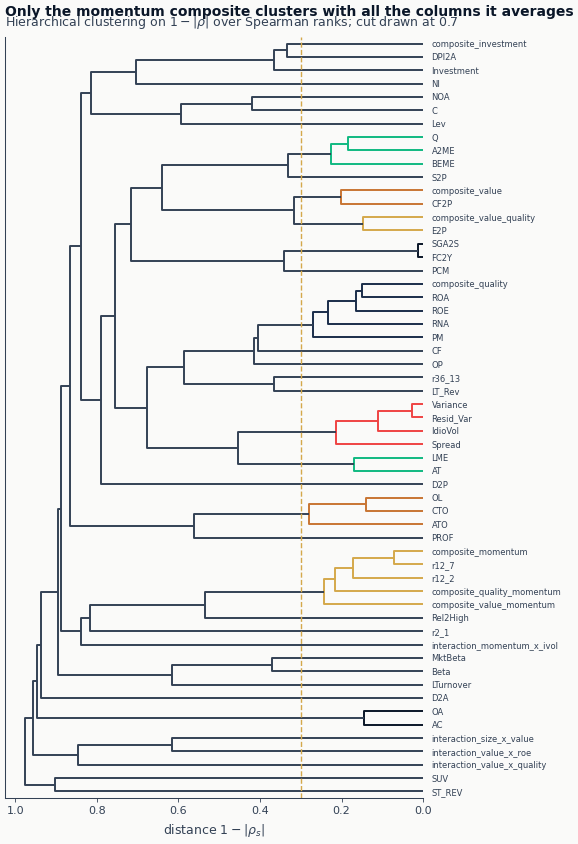

In [19]:
clusters = plot_redundancy_clusters(
    development,
    FEATURE_COLS,
    cut=0.7,
    title="Only the momentum composite clusters with all the columns it averages",
    subtitle=r"Hierarchical clustering on $1-|\rho|$ over Spearman ranks; cut drawn at 0.7",
    alt=(
        "A dendrogram over all 57 columns with a cut line drawn at a distance of 0.7, leaving "
        "37 clusters of which ten hold more than one column. Averaging does not make a composite "
        "redundant with what it averages: composite_momentum is the only one sharing a cluster "
        "with all of its members, r12_2 and r12_7, and the two cross-family momentum composites "
        "sit in that cluster as well. composite_quality shares its cluster with four of its "
        "seven members, composite_value with only CF2P of its six, and composite_investment and "
        "all four interaction columns with none of theirs."
    ),
)

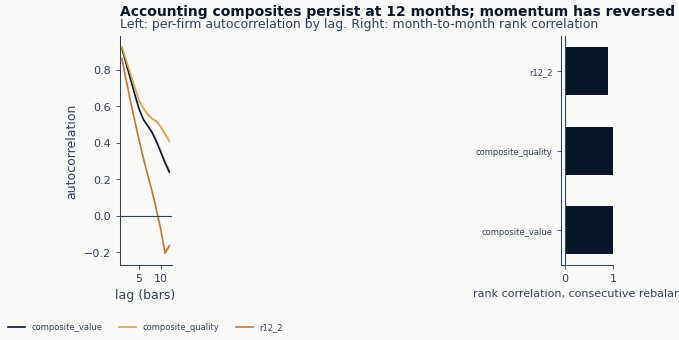

In [20]:
decision_dates = development["timestamp"].unique().sort().to_list()
plot_persistence(
    development,
    ["composite_value", "composite_quality", "r12_2"],
    entity=ENTITY,
    max_lag=12,
    decision_dates=decision_dates,
    title="Accounting composites persist at 12 months; momentum has reversed",
    subtitle=("Left: per-firm autocorrelation by lag. Right: month-to-month rank correlation"),
    alt=(
        "Two panels. On the left, autocorrelation against lag in months for two accounting "
        "composites and 12-month momentum; the accounting series decay slowly and momentum "
        "decays faster. On the right, month-to-month rank correlation for the same three."
    ),
)

### F. Redundancy and persistence, as numbers

The two figures above are read together: a cluster count says how many distinct orderings the
57 columns actually carry, and rank survival says how long any of them lasts. Both are over
development rows only.

In [21]:
n_clusters = len(set(clusters.values()))
largest = max(sum(1 for v in clusters.values() if v == c) for c in set(clusters.values()))
print(f"Redundancy clusters at |rho| > 0.7: {n_clusters} over {len(FEATURE_COLS)} columns")
print(f"Largest cluster: {largest} columns")

survival = (
    development.select(["timestamp", "composite_value", "r12_2"])
    .sort("timestamp")
    .group_by("timestamp")
    .agg(pl.len())
)
print(f"Decision dates before the holdout: {survival.height} months, from {WINDOW_START}")

Redundancy clusters at |rho| > 0.7: 37 over 57 columns
Largest cluster: 5 columns
Decision dates before the holdout: 312 months, from 1990-01-01


## G. Emit

The matrix is written with `write_artifact`, which puts a digest sidecar beside the parquet. The
sidecar records the panel key, this notebook as the writer, and the digest of the input panel
restricted to the columns and window actually consumed - so a later stage can tell whether it is
reading the matrix that was built from the data it thinks it was.

| Artifact | Read by |
|---|---|
| `features/financial.parquet` | `04_evaluation:70`, and the modeling stages downstream of it |
| `features/financial.parquet.digest.json` | nothing yet - it is the provenance record a reader checks by hand, and what stage 04 will declare as an input when it adopts the sidecar |

The previous version also wrote `feature_doc.json`, a description of the families and the
normalization. Nothing in the repository read it, and the register it duplicated now lives in
`setup.yaml`, where a test can reach it. It is not written any more.

In [22]:
matrix = features.select(PANEL_KEY + FEATURE_COLS).sort(PANEL_KEY)

record = write_artifact(
    matrix,
    FEATURES_DIR / "financial.parquet",
    keys=PANEL_KEY,
    written_by="case_studies/us_firm_characteristics/03_financial_features.py",
    inputs={
        "load_firm_characteristics": value_digest(
            firm_chars.select(PANEL_KEY + RELEASED).sort(PANEL_KEY)
        ),
    },
)

print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}")
print(f"  rows {record['n_rows']:,}   digest {record['digest']}")

Wrote case_studies/us_firm_characteristics/features/financial.parquet
  rows 804,530   digest 2bd6a59dadf977d1


## Key takeaways

1. A panel that arrives cross-sectionally ranked moves the timing question upstream. The
   construction here fits nothing and reads no other row, so the contract can be demonstrated by
   rebuilding without the holdout and comparing values rather than argued for in prose.
2. State what an audit can reach. The provider releases complete cases, so its warmup nulls are
   gone and no assertion made here can recover the windows the register records; saying so is
   worth more than an assertion that passes because there is nothing left for it to catch.
3. A composite is only a composite if it averages the member list it declares. The nullity check
   in D.2 is what separates that from a mean over whichever members happened to be present.
4. A null policy keyed on column order is a screen nobody chose. Asserting the completeness the
   release already guarantees says the same thing and fails loudly when it stops being true.
5. The firm identity is part of the artifact's contract, not an implementation detail. Section E
   asserts the one-to-one join against the labels because the previous vintage of this matrix was
   keyed on a positional identifier and joined to nothing.

**Known limitations.** The register's lookbacks are the provider's stated conventions and the
windows some characteristics name, not per-characteristic estimation windows, which the release
does not publish. The `other` family is a residual grouping with no single thesis, so a
family-level reading of it means less than it does for the five named families.

**Next**: [`04_evaluation`](04_evaluation.ipynb) screens these features fold-aware, with HAC
uncertainty and false-discovery control.